# 01. Минимальный первичный EDA для Entity Resolution

Цель ноутбука — быстро понять, с чем работаем перед построением витрин и моделей:

- сколько строк, профилей и `entity_id`;
- корректна ли связь `profile_id -> entity_id`;
- сколько в датасете повторных профилей одного клиента;
- есть ли заметный временной паттерн у повторных регистраций;
- какие identity и feature-колонки реально заполнены.


In [3]:
from pathlib import Path
from math import comb

import numpy as np
import json
import pandas as pd

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

RAW_DATA_DIR = Path('../data')
DATA_PATH = RAW_DATA_DIR / 'split_label_train_V3.snappy.parquet'
DATA_PATH


WindowsPath('../data/split_label_train_V3.snappy.parquet')

## 1. Загрузка данных



In [13]:
df = pd.read_parquet(DATA_PATH, engine='pyarrow')
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

print('shape:', df.shape)
display(df.head(2))
display(df.dtypes)


shape: (68036, 12)
columns: 12


,created_at,first_name,last_name,email,phone,birthday,sex,non_processing_features,realtime_features,fs_features,profile_id,entity_id
0,2025-11-01 00:27:04.995,Анфиса,None,lqvxvltxx@mail.ru,None,None,female,"[device:smartphone, geoname_id:2013348, browse...","{""country"":""RU"",""is_million"":false,""tz_offset""...","[visited_30:250, visited_365:1813, visited_30:...",b25135c7-b4f8-3552-8eb6-46331ceea5c9,7266581b455c33f90f4e2418ab7d12e3ec704935338ecf...
1,2025-11-01 00:38:35.323,Надежда,None,kstpnq.6751@mail.ru,None,None,female,"[device:smartphone, geoname_id:2025339, browse...","{""country"":""RU"",""is_million"":false,""tz_offset""...",[source_site_365:6370],2403b42b-2420-35c2-ac8e-e6572c2920f6,bd0dc28d66040e40ad5303a3ed8f3988973726bb3d0307...


created_at                 datetime64[ns]
first_name                         object
last_name                          object
email                              object
phone                              object
birthday                           object
sex                                object
non_processing_features            object
realtime_features                  object
fs_features                        object
profile_id                         object
entity_id                          object
dtype: object

In [14]:
# Базовая проверка объёма данных
summary_input = {
    'raw_rows': len(df),
    'profiles': df['profile_id'].nunique(),
    'entities': df['entity_id'].nunique()
}
summary_input

{'raw_rows': 68036, 'profiles': 61927, 'entities': 53369}

## 2. Схема и пропуски


In [6]:
expected_columns = [
    'profile_id', 'entity_id', 'created_at',
    'first_name', 'last_name', 'email', 'phone', 'birthday', 'sex',
    'realtime_features', 'fs_features', 'non_processing_features',
]

schema_check = pd.DataFrame({
    'column': expected_columns,
    'exists': [col in df.columns for col in expected_columns],
})

column_overview = []
for col in expected_columns:
    if col not in df.columns:
        column_overview.append({
            'column': col,
            'dtype': None,
            'non_null_rows': 0,
            'null_share': 1.0,
        })
        continue
    column_overview.append({
        'column': col,
        'dtype': str(df[col].dtype),
        'non_null_rows': int(df[col].notna().sum()),
        'null_share': float(df[col].isna().mean()),
    })

column_overview = pd.DataFrame(column_overview).sort_values('null_share', ascending=False)

display(schema_check)
display(column_overview)


,column,exists
0,profile_id,True
1,entity_id,True
2,created_at,True
3,first_name,True
4,last_name,True
5,email,True
6,phone,True
7,birthday,True
8,sex,True
9,realtime_features,True


,column,dtype,non_null_rows,null_share
7,birthday,object,407,0.994018
4,last_name,object,1621,0.976174
6,phone,object,4966,0.927009
3,first_name,object,18479,0.728394
11,non_processing_features,object,67795,0.003542
10,fs_features,object,67795,0.003542
9,realtime_features,object,67795,0.003542
8,sex,object,67984,0.000764
2,created_at,datetime64[ns],68036,0.000000
1,entity_id,object,68036,0.000000


## 3. Гранулярность: строки, профили, entity

Фиксируем базовые размеры датасета и важный sanity-check: один `profile_id` не должен ссылаться на
несколько разных `entity_id`. Если такие строки есть, это ломает обучение и оценку качества.


In [7]:
base_counts = pd.DataFrame([
    {'metric': 'rows', 'value': len(df)},
    {'metric': 'profiles', 'value': df['profile_id'].nunique(dropna=True)},
    {'metric': 'entities', 'value': df['entity_id'].nunique(dropna=True)},
    {'metric': 'min_created_at', 'value': df['created_at'].min()},
    {'metric': 'max_created_at', 'value': df['created_at'].max()},
])

profile_event_counts = df.groupby('profile_id', dropna=False).size().rename('event_count')
profile_event_summary = profile_event_counts.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame('event_count')

profile_entity_nunique = df.groupby('profile_id', dropna=False)['entity_id'].nunique(dropna=True)
profile_entity_check = pd.DataFrame([
    {'metric': 'profiles_without_entity_id', 'value': int(profile_entity_nunique.eq(0).sum())},
    {'metric': 'profiles_with_one_entity_id', 'value': int(profile_entity_nunique.eq(1).sum())},
    {'metric': 'profiles_with_multiple_entity_id', 'value': int(profile_entity_nunique.gt(1).sum())},
])

display(base_counts)
display(profile_event_summary)
display(profile_entity_check)


,metric,value
0,rows,68036
1,profiles,61927
2,entities,53369
3,min_created_at,2025-11-01 00:27:04.995000
4,max_created_at,2026-05-11 23:37:47.651000


,event_count
count,61927.000000
mean,1.098648
std,0.539293
min,1.000000
50%,1.000000
90%,1.000000
95%,2.000000
99%,3.000000
max,29.000000


,metric,value
0,profiles_without_entity_id,0
1,profiles_with_one_entity_id,61927
2,profiles_with_multiple_entity_id,0


## 4. Сколько дублей в датасете

Смотрим:

- сколько всего профилей и клиентов;
- сколько клиентов имеют больше одного профиля;
- сколько профилей лежат у таких клиентов;
- сколько существует настоящих пар профилей одного клиента.

Последнее число важно для pair-модели: оно показывает, сколько положительных пар вообще есть среди полного перебора всех профилей.


In [8]:
profile_core = (
    df.groupby('profile_id', dropna=False)
    .agg(entity_id=('entity_id', 'first'))
    .reset_index()
)

entity_sizes = profile_core.groupby('entity_id', dropna=False)['profile_id'].nunique().rename('entity_profile_count')

total_profiles = int(profile_core['profile_id'].nunique(dropna=True))
total_entities = int(entity_sizes.shape[0])
duplicate_entities = int(entity_sizes.gt(1).sum())
profiles_in_duplicate_entities = int(entity_sizes[entity_sizes.gt(1)].sum())
positive_pairs = int(sum(comb(int(n), 2) for n in entity_sizes if n > 1))
total_possible_pairs = total_profiles * (total_profiles - 1) // 2

summary_rows = [
    {'metric': 'total_profiles', 'count': total_profiles, 'share': 1.0},
    {'metric': 'total_entities', 'count': total_entities, 'share': 1.0},
    {'metric': 'duplicate_entities', 'count': duplicate_entities, 'share': duplicate_entities / total_entities},
    {'metric': 'profiles_in_duplicate_entities', 'count': profiles_in_duplicate_entities, 'share': profiles_in_duplicate_entities / total_profiles},
    {'metric': 'positive_pairs', 'count': positive_pairs, 'share': positive_pairs / total_possible_pairs},
    {'metric': 'total_possible_profile_pairs', 'count': total_possible_pairs, 'share': 1.0},
]
duplicate_summary = pd.DataFrame(summary_rows)

entity_size_distribution = (
    entity_sizes.value_counts()
    .sort_index()
    .rename_axis('entity_profile_count')
    .reset_index(name='n_entities')
)
entity_size_distribution['entity_share'] = entity_size_distribution['n_entities'] / total_entities

display(duplicate_summary)
display(entity_size_distribution)


,metric,count,share
0,total_profiles,61927,1.000000
1,total_entities,53369,1.000000
2,duplicate_entities,8073,0.151268
3,profiles_in_duplicate_entities,16631,0.268558
4,positive_pairs,16363,0.000009
5,total_possible_profile_pairs,1917445701,1.000000


,entity_profile_count,n_entities,entity_share
0,1,45296,0.848732
1,2,7808,0.146302
2,3,227,0.004253
3,4,26,0.000487
4,5,4,0.000075
5,6,3,0.000056
6,7,1,0.000019
7,10,1,0.000019
8,22,1,0.000019
9,37,1,0.000019


## 5. Время регистраций-дублей

Смотрим как распределены повторные регистрации одного клиента по частям суток.


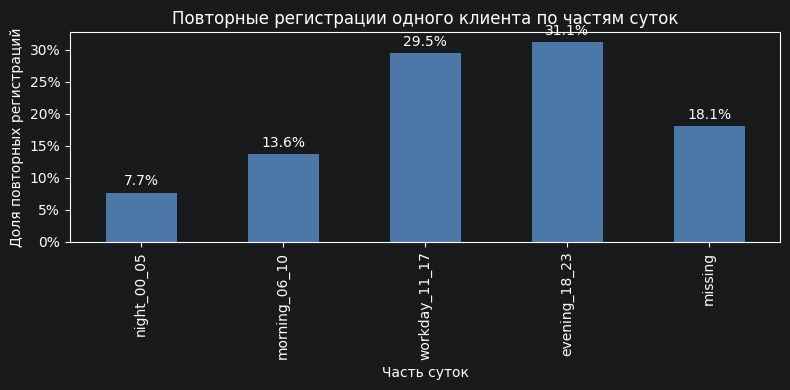

In [9]:
def parse_realtime_features(value):
    if isinstance(value, dict):
        return value
    if isinstance(value, str):
        try:
            return json.loads(value)
        except Exception:
            return {}
    return {}


def daypart_bucket(hour):
    if pd.isna(hour):
        return 'missing'
    hour = int(hour)
    if 0 <= hour <= 5:
        return 'night_00_05'
    if 6 <= hour <= 10:
        return 'morning_06_10'
    if 11 <= hour <= 17:
        return 'workday_11_17'
    return 'evening_18_23'

registration_time = df[['profile_id', 'entity_id', 'created_at', 'realtime_features']].copy()
registration_time['profile_id'] = registration_time['profile_id'].astype(str)
registration_time['entity_id'] = registration_time['entity_id'].astype(str)
registration_time['created_at'] = pd.to_datetime(registration_time['created_at'], errors='coerce')
registration_time['rt_dict'] = registration_time['realtime_features'].map(parse_realtime_features)
registration_time['local_hour'] = pd.to_numeric(registration_time['rt_dict'].map(lambda x: x.get('local_hour')), errors='coerce')

profile_registration_time = (
    registration_time
    .sort_values(['profile_id', 'created_at'])
    .groupby('profile_id', as_index=False)
    .first()[['profile_id', 'entity_id', 'created_at', 'local_hour']]
    .sort_values(['entity_id', 'created_at', 'profile_id'])
)
profile_registration_time['registration_order_in_entity'] = profile_registration_time.groupby('entity_id').cumcount() + 1
profile_registration_time['is_duplicate_registration'] = profile_registration_time['registration_order_in_entity'].gt(1)
profile_registration_time['local_daypart'] = profile_registration_time['local_hour'].map(daypart_bucket)

duplicate_registration_daypart_summary = (
    profile_registration_time[profile_registration_time['is_duplicate_registration']]
    ['local_daypart']
    .value_counts(dropna=False)
    .rename_axis('local_daypart')
    .reset_index(name='duplicate_registrations')
)
duplicate_registration_daypart_summary['share'] = (
    duplicate_registration_daypart_summary['duplicate_registrations']
    / duplicate_registration_daypart_summary['duplicate_registrations'].sum()
)

daypart_order = ['night_00_05', 'morning_06_10', 'workday_11_17', 'evening_18_23', 'missing']
duplicate_registration_daypart_summary['local_daypart'] = pd.Categorical(
    duplicate_registration_daypart_summary['local_daypart'],
    categories=daypart_order,
    ordered=True,
)
duplicate_registration_daypart_summary = duplicate_registration_daypart_summary.sort_values('local_daypart')

ax = duplicate_registration_daypart_summary.plot.bar(
    x='local_daypart',
    y='share',
    legend=False,
    figsize=(8, 4),
    color='#4C78A8',
)
ax.set_title('Повторные регистрации одного клиента по частям суток')
ax.set_xlabel('Часть суток')
ax.set_ylabel('Доля повторных регистраций')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
ax.bar_label(ax.containers[0], labels=[f'{v:.1%}' for v in duplicate_registration_daypart_summary['share']], padding=3)
ax.figure.tight_layout()


## 6. Заполненность identity-полей

Смотрим только практичный минимум: насколько поле заполнено на уровне профиля и часто ли у одного `profile_id` встречается несколько разных значений.


In [10]:
identity_cols = [col for col in ['first_name', 'last_name', 'email', 'phone', 'birthday', 'sex'] if col in df.columns]

identity_profile_report = []
for col in identity_cols:
    by_profile = df.groupby('profile_id', dropna=False)[col].nunique(dropna=True)
    identity_profile_report.append({
        'column': col,
        'filled_event_share': float(df[col].notna().mean()),
        'profiles_with_value': int(by_profile.gt(0).sum()),
        'profile_coverage': float(by_profile.gt(0).mean()),
        'profiles_with_multiple_values': int(by_profile.gt(1).sum()),
        'multi_value_profile_share': float(by_profile.gt(1).mean()),
    })

identity_profile_report = pd.DataFrame(identity_profile_report).sort_values('profile_coverage', ascending=False)
display(identity_profile_report)


,column,filled_event_share,profiles_with_value,profile_coverage,profiles_with_multiple_values,multi_value_profile_share
2,email,1.000000,61927,1.000000,0,0.0
5,sex,0.999236,61880,0.999241,0,0.0
0,first_name,0.271606,17042,0.275195,0,0.0
3,phone,0.072991,4656,0.075185,0,0.0
1,last_name,0.023826,1487,0.024012,0,0.0
4,birthday,0.005982,369,0.005959,0,0.0


## 7. Сырые feature-колонки

`realtime_features`, `fs_features`, `non_processing_features` дальше разбираются в витрине. Здесь достаточно понять, есть ли они и насколько заполнены.


In [11]:
feature_columns = [col for col in ['realtime_features', 'fs_features', 'non_processing_features'] if col in df.columns]

feature_column_overview = pd.DataFrame([
    {
        'column': col,
        'filled_rows': int(df[col].notna().sum()),
        'filled_share': float(df[col].notna().mean()),
    }
    for col in feature_columns
])

display(feature_column_overview)


,column,filled_rows,filled_share
0,realtime_features,67795,0.996458
1,fs_features,67795,0.996458
2,non_processing_features,67795,0.996458
